In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import seaborn as sns

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (7.35, 4.40),
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "viridis",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="semibold",
        va="top",
        ha="left",
        transform=None,
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# Example: The Duffing Oscillator


The Duffing oscillator models a periodically forced oscillator with a cubic restoring term:

$$
\ddot{x}(t) + \delta \dot{x}(t) + \alpha x(t) + \beta x(t)^3
= \gamma \cos(\omega t).
$$

Here, $t$ denotes time, $x(t)$ is displacement, $\delta$ is the damping coefficient, $\alpha$ and $\beta$ are the linear and cubic stiffness coefficients, $\gamma$ is the forcing amplitude, and $\omega$ is the forcing angular frequency. Introduce the velocity $v(t)=\dot{x}(t)$ and the state $\mathbf{y}(t)=(x(t),v(t))^{\mathsf T}\in\mathbb{R}^2$. The second-order equation is equivalent to

$$
\begin{aligned}
\dot{x}(t) &= v(t), \\
\dot{v}(t) &= \gamma \cos(\omega t)-\delta v(t)-\alpha x(t)-\beta x(t)^3.
\end{aligned}
$$

We fix the initial state at $\mathbf{y}(0)=(0,0)^{\mathsf T}$ and collect the five dynamical parameters in

$$
\boldsymbol{\theta}=(\alpha,\beta,\gamma,\delta,\omega)^{\mathsf T}\in\mathbb{R}^5.
$$

For $t\in[0,50]$, the vector field $\mathbf{f}:\mathbb{R}^2\times[0,50]\times\mathbb{R}^5\to\mathbb{R}^2$ is

$$
\mathbf{f}(\mathbf{y},t;\boldsymbol{\theta})
=\begin{pmatrix}
v \\
\gamma \cos(\omega t)-\delta v-\alpha x-\beta x^3
\end{pmatrix},
\qquad \mathbf{y}=(x,v)^{\mathsf T}.
$$

We begin with the nominal parameter vector $\boldsymbol{\mu}=(1,5,0.37,0.1,1)^{\mathsf T}$. The following JAX code solves the fixed-initial-state problem using the [Diffrax package](https://docs.kidger.site/diffrax/) and its explicit Runge–Kutta solver `Tsit5`.



In [3]:
import numpy as np
import jax.numpy as jnp
from diffrax import diffeqsolve, ForwardMode, ODETerm, SaveAt, Tsit5

def vector_field(t, y, theta):
    alpha, beta, gamma, delta, omega = theta
    x = y[0]
    v = y[1]
    return jnp.array(
        [
            v,
            - alpha * x - beta * x ** 3 - delta * v + gamma * jnp.cos(omega * t)
        ]
    )


mu = jnp.array([
    1.0,  # alpha
    5.0,  # beta
    0.37, # gamma
    0.1,  # delta
    1.0,  # omega
])

# The numerical solver to use.
solver = Tsit5()
# Times at which to store the solution.
saveat = SaveAt(ts=jnp.linspace(0, 50, 2000))
# The differential equation term.
term = ODETerm(vector_field)
# The solution at the nominal parameter vector.
sol = diffeqsolve(
    term,
    solver,
    t0=0,                       # Initial time
    t1=50,                      # Terminal time
    dt0=0.1,                    # Fixed step size
    y0=jnp.array([0.0, 0.0]),   # Initial value
    args=mu,
    saveat=saveat
)

The array `sol.ys` has one row for each saved time and one column for each state component:

In [4]:
print(sol.ys.shape)

(2000, 2)


The corresponding time histories and phase portrait are:

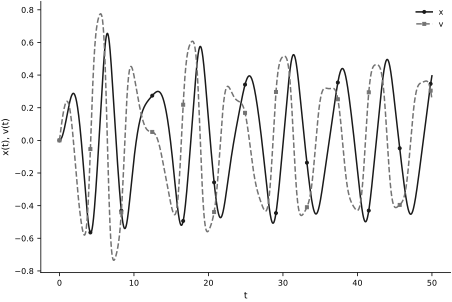

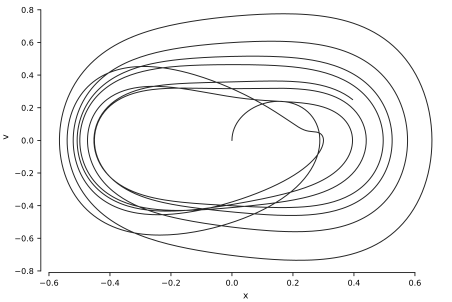

In [5]:
fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"])
markevery = max(1, len(sol.ts) // 12)
ax.plot(sol.ts, sol.ys[:, 0], color="0.10", linestyle="-", marker="o", markevery=markevery, markersize=3, label="x")
ax.plot(sol.ts, sol.ys[:, 1], color="0.45", linestyle="--", marker="s", markevery=markevery, markersize=3, label="v")
ax.set(xlabel="t", ylabel="x(t), v(t)")
ax.legend(frameon=False)
finalize_axes(keep_box=False)

fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"])
ax.plot(sol.ys[:, 0], sol.ys[:, 1], color="0.15", lw=1)
ax.set(xlabel="x", ylabel="v")
sns.despine(trim=True);


For this nominal parameter vector, the trajectory approaches an apparently stable periodic orbit. We now assign independent Gaussian uncertainty to the five dynamical parameters while keeping the initial state fixed. Let $\boldsymbol{\Theta}$ denote the random parameter vector, let $\boldsymbol{\mu}$ be its mean, and let $\Sigma$ be its covariance matrix. Each marginal standard deviation is 5% of the corresponding nominal value:

$$
\boldsymbol{\Theta} \sim \mathcal{N}(\boldsymbol{\mu},\Sigma),
\qquad
\Sigma=
\begin{pmatrix}
0.05^2 & 0 & 0 & 0 & 0 \\
0 & 0.25^2 & 0 & 0 & 0 \\
0 & 0 & 0.0185^2 & 0 & 0 \\
0 & 0 & 0 & 0.005^2 & 0 \\
0 & 0 & 0 & 0 & 0.05^2
\end{pmatrix}.
$$

In [6]:
Sigma = np.diag((0.05 * np.asarray(mu)) ** 2)

The function below maps a five-component parameter vector to the 2,000 stored values of $\mathbf{y}(t)=(x(t),v(t))^{\mathsf T}$. The initial state remains fixed at $(0,0)^{\mathsf T}$. The `ForwardMode()` setting allows JAX to propagate forward-mode derivatives through the Diffrax solve.

In [7]:
def solve_duffing(theta):
    # The numerical solver to use.
    solver = Tsit5()
    # Times at which to store the solution.
    saveat = SaveAt(ts=jnp.linspace(0, 50, 2000))
    # The differential equation term.
    term = ODETerm(vector_field)
    # The solution for one parameter vector.
    sol = diffeqsolve(
        term,
        solver,
        t0=0,                       # Initial time
        t1=50,                      # Terminal time
        dt0=0.1,                    # Fixed step size
        y0=jnp.array([0.0, 0.0]),   # Initial value
        args=theta,
        adjoint=ForwardMode(),
        saveat=saveat
    )
    return sol.ys

Forward-mode automatic differentiation constructs the solution Jacobian efficiently because the solver has five inputs and 4,000 stored scalar outputs. We use `jacfwd` for this derivative and `jit` to compile both computations.

In [8]:
from jax import jacfwd, jit

jit_solve_duffing = jit(solve_duffing)
jit_jac_solve_duffing = jit(jacfwd(solve_duffing))

# Evaluate the solution and its Jacobian at the mean parameter vector.
sol_mu = jit_solve_duffing(mu)
jac_sol_mu = jit_jac_solve_duffing(mu)

The uncertain parameters produce the random state $\mathbf{Y}(t)=\mathbf{y}(t;\boldsymbol{\Theta})$, which is generally non-Gaussian because the parameter-to-state map is nonlinear. The first-order approximation from the preceding section is

$$
\widetilde{\mathbf{Y}}(t)
=\mathbf{y}(t;\boldsymbol{\mu})
+S(t)(\boldsymbol{\Theta}-\boldsymbol{\mu}),
$$

where $S(t)\in\mathbb{R}^{2\times 5}$ is the solution Jacobian evaluated at $\boldsymbol{\mu}$. Because $\boldsymbol{\Theta}$ is Gaussian, $\widetilde{\mathbf{Y}}$ is a vector-valued Gaussian process. The array `sol_mu` stores its mean $\mathbf{y}(t;\boldsymbol{\mu})$ at the 2,000 saved times, and `jac_sol_mu` stores $S(t)$ at those times.

Let $t_0,\ldots,t_{1999}$ denote the saved times. For $k,r\in\{0,\ldots,1999\}$, state indices $i,j\in\{0,1\}$, and parameter indices $\ell,m\in\{0,\ldots,4\}$, define

$$
S_{ki\ell}
=\left.\frac{\partial y_i(t_k;\boldsymbol{\theta})}{\partial\theta_{\ell}}\right|_{\boldsymbol{\theta}=\boldsymbol{\mu}}.
$$

The covariance between state component $i$ at time $t_k$ and state component $j$ at time $t_r$ is

$$
C_{krij}
=\sum_{\ell=0}^{4}\sum_{m=0}^{4}
S_{ki\ell}\Sigma_{\ell m}S_{rjm}.
$$

The figures below require only the same-time component variances $C_{kkii}$. NumPy's [`einsum`](https://numpy.org/doc/stable/reference/generated/numpy.einsum.html) computes these variances directly:

In [9]:
marginal_var = np.einsum("kil,lm,kim->ki", jac_sol_mu, Sigma, jac_sol_mu)
print(marginal_var.shape)

(2000, 2)


Taking the square root of each marginal variance gives the pointwise standard deviation of the linearized state:

In [10]:
x_std = np.sqrt(marginal_var[:, 0])
v_std = np.sqrt(marginal_var[:, 1])

We can now plot the nominal trajectory together with pointwise bands extending two standard deviations on either side:

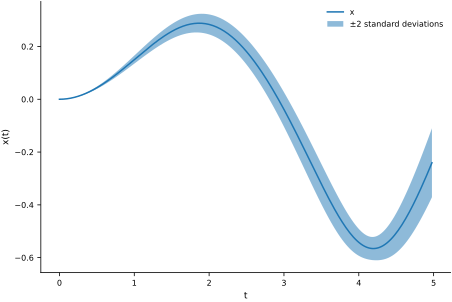

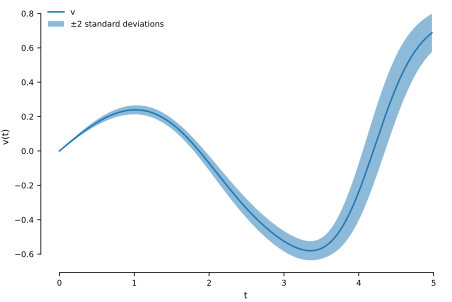

In [11]:
ts = np.asarray(sol.ts)
steps_to_plot = 200
fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"])
ax.plot(ts[:steps_to_plot], sol_mu[:steps_to_plot, 0], label="x")
ax.fill_between(
    ts[:steps_to_plot],
    sol_mu[:steps_to_plot, 0] - 2 * x_std[:steps_to_plot],
    sol_mu[:steps_to_plot, 0] + 2 * x_std[:steps_to_plot],
    alpha=0.5,
    label=r"$\pm 2$ standard deviations",
)
ax.set(xlabel="t", ylabel="x(t)")
ax.legend(frameon=False)
finalize_axes(keep_box=False)

fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"])
ax.plot(ts[:steps_to_plot], sol_mu[:steps_to_plot, 1], label="v")
ax.fill_between(
    ts[:steps_to_plot],
    sol_mu[:steps_to_plot, 1] - 2 * v_std[:steps_to_plot],
    sol_mu[:steps_to_plot, 1] + 2 * v_std[:steps_to_plot],
    alpha=0.5,
    label=r"$\pm 2$ standard deviations",
)
ax.set(xlabel="t", ylabel="v(t)")
ax.legend(frameon=False)
sns.despine(trim=True)


These plots show only the first 200 saved times, corresponding to approximately $0\leq t\leq 5$. The local approximation becomes less accurate later; the Monte Carlo comparison below makes that loss of accuracy visible.

An independent Monte Carlo calculation provides a reference for assessing the local approximation. The JAX transformation `vmap` applies `solve_duffing` independently to each row of a parameter-sample array, and `jit` compiles the batched calculation:

In [12]:
from jax import jit, vmap

many_solve_duffing = jit(vmap(solve_duffing, in_axes=(0,)))

We draw 1,000 reproducible samples from $\mathcal{N}(\boldsymbol{\mu},\Sigma)$. This sample size keeps the notebook practical while providing a useful comparison. Let $L$ be the lower-triangular Cholesky factor of $\Sigma$, so that $\Sigma=LL^{\mathsf T}$. Let $\mathbf{0}\in\mathbb{R}^5$ be the zero vector and $I_5$ the $5\times 5$ identity matrix. For a standard normal vector $\mathbf{z}\sim\mathcal{N}(\mathbf{0},I_5)$, the transformation $\boldsymbol{\mu}+L\mathbf{z}$ has the required distribution:

In [13]:
num_thetas = 1_000
rng = np.random.default_rng(0)
L = np.linalg.cholesky(Sigma)
mu_np = np.asarray(mu)
standard_normal_samples = rng.standard_normal(
    (num_thetas, mu_np.size), dtype=mu_np.dtype
)
thetas = standard_normal_samples @ L.T + mu_np
sols = np.asarray(many_solve_duffing(jnp.asarray(thetas)))

The sample mean and sample standard deviation estimate the corresponding state moments:

In [14]:
mean_sol = np.mean(sols, axis=0)
std_sol = np.std(sols, axis=0)

The Monte Carlo mean and pointwise two-standard-deviation bands over the same early-time interval are:

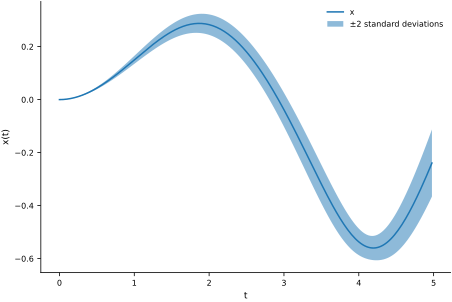

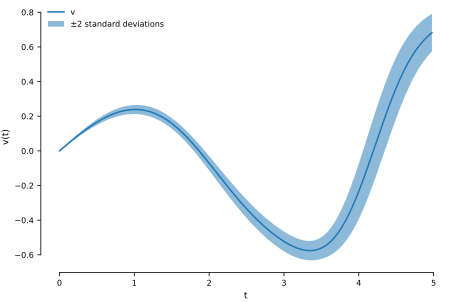

In [15]:
fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"])
ax.plot(ts[:steps_to_plot], mean_sol[:steps_to_plot, 0], label="x")
ax.fill_between(
    ts[:steps_to_plot],
    mean_sol[:steps_to_plot, 0] - 2 * std_sol[:steps_to_plot, 0],
    mean_sol[:steps_to_plot, 0] + 2 * std_sol[:steps_to_plot, 0],
    alpha=0.5,
    label=r"$\pm 2$ standard deviations",
)
ax.set(xlabel="t", ylabel="x(t)")
ax.legend(frameon=False)
finalize_axes(keep_box=False)

fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"])
ax.plot(ts[:steps_to_plot], mean_sol[:steps_to_plot, 1], label="v")
ax.fill_between(
    ts[:steps_to_plot],
    mean_sol[:steps_to_plot, 1] - 2 * std_sol[:steps_to_plot, 1],
    mean_sol[:steps_to_plot, 1] + 2 * std_sol[:steps_to_plot, 1],
    alpha=0.5,
    label=r"$\pm 2$ standard deviations",
)
ax.set(xlabel="t", ylabel="v(t)")
ax.legend(frameon=False)
sns.despine(trim=True);


The bands are visually similar over this interval. A direct comparison begins with the mean functions:

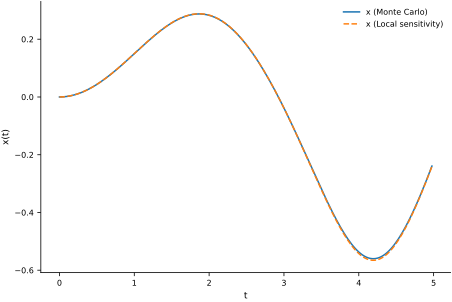

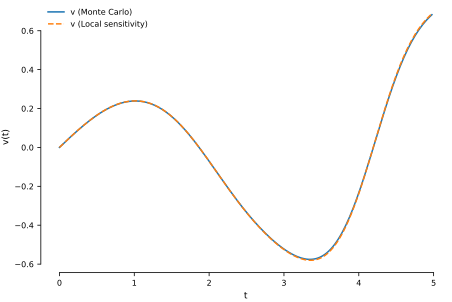

In [16]:
fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"])
ax.plot(ts[:steps_to_plot], mean_sol[:steps_to_plot, 0], label="x (Monte Carlo)")
ax.plot(ts[:steps_to_plot], sol_mu[:steps_to_plot, 0], '--', label="x (Local sensitivity)")
ax.set(xlabel="t", ylabel="x(t)")
ax.legend(frameon=False)
finalize_axes(keep_box=False)

fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"])
ax.plot(ts[:steps_to_plot], mean_sol[:steps_to_plot, 1], label="v (Monte Carlo)")
ax.plot(ts[:steps_to_plot], sol_mu[:steps_to_plot, 1], '--', label="v (Local sensitivity)")
ax.set(xlabel="t", ylabel="v(t)")
ax.legend(frameon=False)
sns.despine(trim=True);


The mean functions agree closely. We next compare the standard deviations:

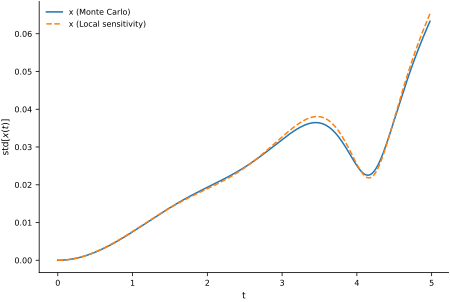

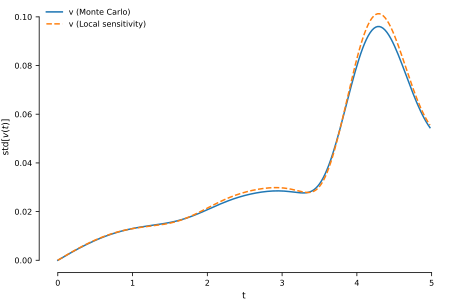

In [17]:
fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"])
ax.plot(ts[:steps_to_plot], std_sol[:steps_to_plot, 0], label="x (Monte Carlo)")
ax.plot(ts[:steps_to_plot], x_std[:steps_to_plot], '--', label="x (Local sensitivity)")
ax.set(xlabel="t", ylabel=r"$\mathrm{std}[x(t)]$")
ax.legend(frameon=False)
finalize_axes(keep_box=False)

fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"])
ax.plot(ts[:steps_to_plot], std_sol[:steps_to_plot, 1], label="v (Monte Carlo)")
ax.plot(ts[:steps_to_plot], v_std[:steps_to_plot], '--', label="v (Local sensitivity)")
ax.set(xlabel="t", ylabel=r"$\mathrm{std}[v(t)]$")
ax.legend(frameon=False)
sns.despine(trim=True);


The standard deviations also agree closely over the early-time interval. To examine the useful time horizon of the local approximation, we now extend the comparison to the first 1,000 saved times. The mean functions are:

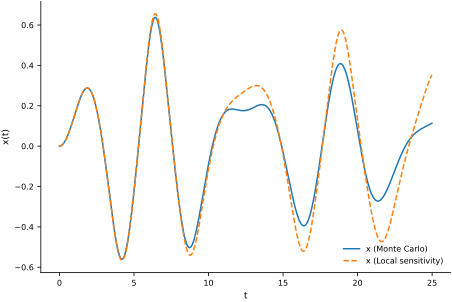

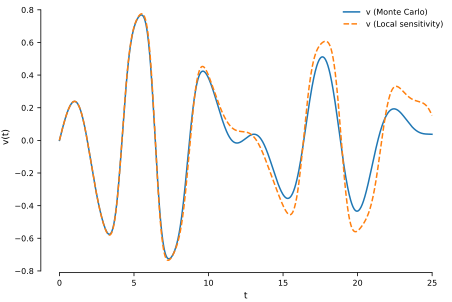

In [18]:
steps_to_plot = 1_000

fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"])
ax.plot(ts[:steps_to_plot], mean_sol[:steps_to_plot, 0], label="x (Monte Carlo)")
ax.plot(ts[:steps_to_plot], sol_mu[:steps_to_plot, 0], '--', label="x (Local sensitivity)")
ax.set(xlabel="t", ylabel="x(t)")
ax.legend(frameon=False)
finalize_axes(keep_box=False)

fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"])
ax.plot(ts[:steps_to_plot], mean_sol[:steps_to_plot, 1], label="v (Monte Carlo)")
ax.plot(ts[:steps_to_plot], sol_mu[:steps_to_plot, 1], '--', label="v (Local sensitivity)")
ax.set(xlabel="t", ylabel="v(t)")
ax.legend(frameon=False)
sns.despine(trim=True);


The corresponding standard deviations are:

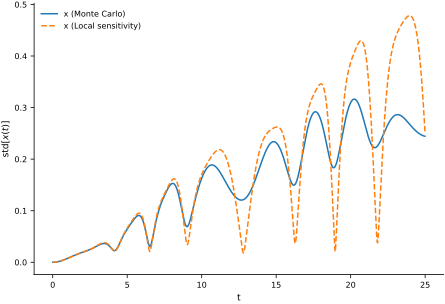

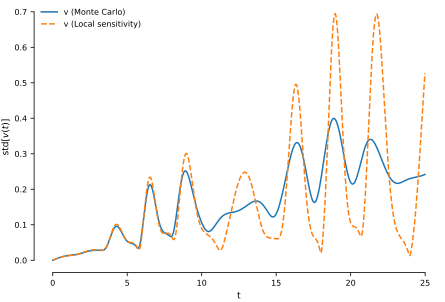

In [19]:
fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"])
ax.plot(ts[:steps_to_plot], std_sol[:steps_to_plot, 0], label="x (Monte Carlo)")
ax.plot(ts[:steps_to_plot], x_std[:steps_to_plot], '--', label="x (Local sensitivity)")
ax.set(xlabel="t", ylabel=r"$\mathrm{std}[x(t)]$")
ax.legend(frameon=False)
finalize_axes(keep_box=False)

fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"])
ax.plot(ts[:steps_to_plot], std_sol[:steps_to_plot, 1], label="v (Monte Carlo)")
ax.plot(ts[:steps_to_plot], v_std[:steps_to_plot], '--', label="v (Local sensitivity)")
ax.set(xlabel="t", ylabel=r"$\mathrm{std}[v(t)]$")
ax.legend(frameon=False)
sns.despine(trim=True);


The local approximation agrees with the Monte Carlo moments over the early-time window, but the discrepancy grows at later times. Over the uncertain parameter region, the parameter-to-state map is then no longer represented accurately by its first-order expansion about $\boldsymbol{\mu}$. The useful time horizon depends on both the uncertainty scale and the dynamics.